# Laboratorio 2
## Minería de Datos


En este notebook se encuentra los resultados obtenidos.

A continuación se siguen las secciones pedidas en el enunciado (1.1 a 1.6).

## 1.1. Preprocesamiento del dataset


En esta sección se carga el archivo `movies_2026.csv`, se valida que estén presentes las columnas requeridas y se construye un dataset de trabajo (`df_model`) con variables limpias y transformadas para clustering.



- Se descartan identificadores y textos como `id` y `title` para el cálculo de distancias, porque no reflejan similitud semántica entre películas.

- Se mantienen variables **numéricas** como presupuesto, ingresos, popularidad, votos, cantidad de géneros, compañías, países y reparto, y el año de estreno.

- Se incluyen variables **categóricas simples**: `originalLanguage` (agrupada en los idiomas más frecuentes + categoría "OTHER") y `video` (normalizada a valores coherentes).

- Sobre algunas variables numéricas fuertemente sesgadas (`budget`, `revenue`, `popularity`, `voteCount`) se aplica una transformación logarítmica `log1p` para reducir el efecto de outliers.



Con estas decisiones, las variables que **no** aportan directamente a la formación de grupos (identificadores, textos libres u otros campos no incluidos en `NUMERIC_COLS` o `CATEGORICAL_COLS`) se usan solo como referencia o para interpretar los clusters, pero no para calcular las distancias.

In [ ]:
# Ejecutar una sola vez por entorno (puede tardar unos minutos).
%pip install pandas numpy scikit-learn matplotlib seaborn jupyter pyclustertend factor-analyzer mlxtend umap-learn

In [34]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch, AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    pairwise_distances,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from scipy.cluster.hierarchy import linkage, leaves_list
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


In [35]:
CSV_PATH = Path('/tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026.csv')
if not CSV_PATH.exists():
    local_candidate = Path.cwd() / 'movies_2026.csv'
    if local_candidate.exists():
        CSV_PATH = local_candidate

OUTPUT_PATH = Path('/tmp/codex-lab2-publish.kgl7pm/Lab2/movies_2026_clusters_initial.csv')
if not OUTPUT_PATH.parent.exists():
    OUTPUT_PATH = Path.cwd() / 'movies_2026_clusters_initial.csv'

REQUIRED_COLUMNS = [
    'id', 'title', 'budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
    'castWomenAmount', 'castMenAmount', 'releaseYear', 'originalLanguage', 'video'
]

NUMERIC_COLS = [
    'budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount',
    'castWomenAmount', 'castMenAmount', 'releaseYear'
]

CATEGORICAL_COLS = ['originalLanguage', 'video']
LOG_COLS = ['budget', 'revenue', 'popularity', 'voteCount']


def read_csv_robusto(path: Path) -> pd.DataFrame:
    read_kwargs = {
        'na_values': ['NA', ''],
        'keep_default_na': True,
        'low_memory': False,
    }
    try:
        return pd.read_csv(path, encoding='utf-8', encoding_errors='replace', **read_kwargs)
    except TypeError:
        # Compatibilidad con versiones de pandas sin encoding_errors.
        with open(path, 'r', encoding='utf-8', errors='replace', newline='') as f:
            return pd.read_csv(f, **read_kwargs)


def validate_required_columns(df) -> None:
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f'Faltan columnas requeridas: {missing}')


def normalize_video(series) -> pd.Series:
    s = series.copy()
    s = s.astype('string').str.strip().str.upper()
    s = s.fillna('UNKNOWN')
    s = s.replace({'': 'UNKNOWN', '<NA>': 'UNKNOWN', 'NA': 'UNKNOWN'})
    return s


def bucket_top_languages(series, top_n=10) -> pd.Series:
    s = series.astype('string').str.strip().str.lower().fillna('unknown')
    s = s.replace({'': 'unknown', 'na': 'unknown', '<na>': 'unknown'})
    top_values = s.value_counts(dropna=False).head(top_n).index
    s = s.where(s.isin(top_values), 'other')
    return s.str.upper()


def build_feature_dataframe(df) -> pd.DataFrame:
    out = df.copy()

    # Conversión numérica robusta.
    for col in NUMERIC_COLS:
        out[col] = pd.to_numeric(out[col], errors='coerce')

    # Normalización de categóricas simples.
    out['video'] = normalize_video(out['video'])
    out['originalLanguage'] = bucket_top_languages(out['originalLanguage'], top_n=10)

    # Evitar problemas con log1p en valores negativos.
    for col in LOG_COLS:
        out[col] = out[col].where(out[col].isna() | (out[col] >= 0), np.nan)
        out[col] = np.log1p(out[col])

    return out


def make_one_hot_encoder():
    # Compatibilidad sklearn: sparse_output (nuevo) vs sparse (antiguo).
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else np.asarray(X)


def build_kmeans(n_clusters: int, random_state: int):
    try:
        return KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    except TypeError:
        return KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)


def build_minibatch_kmeans(n_clusters: int, random_state: int):
    try:
        return MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init='auto',
            batch_size=1024,
        )
    except TypeError:
        return MiniBatchKMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=10,
            batch_size=1024,
        )


def build_birch(n_clusters: int, random_state: int):
    # random_state no aplica a Birch; se mantiene en la firma para homogeneidad.
    _ = random_state
    return Birch(n_clusters=n_clusters, threshold=0.5, branching_factor=50)


def evaluate_algorithm_grid(X_transformed, configs, k_values, random_state=42) -> pd.DataFrame:
    records = []
    n_samples = X_transformed.shape[0]

    for algorithm_name, cfg in configs.items():
        builder = cfg['builder']

        for k in k_values:
            t0 = time.perf_counter()
            row = {
                'algorithm': algorithm_name,
                'k': int(k),
                'status': 'ok',
                'silhouette_score': np.nan,
                'calinski_harabasz_score': np.nan,
                'davies_bouldin_score': np.nan,
                'inertia': np.nan,
                'runtime_sec': np.nan,
                'n_clusters_efectivos': np.nan,
                'cluster_max_share': np.nan,
                'error': None,
            }
            try:
                model = builder(int(k), random_state)
                if hasattr(model, 'fit_predict'):
                    labels = model.fit_predict(X_transformed)
                else:
                    model.fit(X_transformed)
                    labels = getattr(model, 'labels_', None)
                    if labels is None:
                        raise RuntimeError('El modelo no expuso etiquetas de cluster')

                elapsed = time.perf_counter() - t0
                labels = np.asarray(labels)
                unique_labels, counts = np.unique(labels, return_counts=True)
                n_eff = int(len(unique_labels))
                max_share = float(counts.max() / counts.sum()) if counts.size else np.nan
                row.update({
                    'runtime_sec': elapsed,
                    'n_clusters_efectivos': n_eff,
                    'cluster_max_share': max_share,
                    'inertia': float(getattr(model, 'inertia_', np.nan)) if hasattr(model, 'inertia_') else np.nan,
                })

                if n_eff < 2:
                    row['status'] = 'invalid_clusters'
                    records.append(row)
                    continue

                sil_kwargs = {}
                if n_samples > 5000:
                    sil_kwargs = {'sample_size': 5000, 'random_state': random_state}

                row['silhouette_score'] = float(silhouette_score(X_transformed, labels, **sil_kwargs))
                row['calinski_harabasz_score'] = float(calinski_harabasz_score(X_transformed, labels))
                row['davies_bouldin_score'] = float(davies_bouldin_score(X_transformed, labels))
            except Exception as exc:
                row['status'] = 'error'
                row['runtime_sec'] = time.perf_counter() - t0
                row['error'] = str(exc)

            records.append(row)

    return pd.DataFrame(records)


def select_best_model(results_df) -> dict:
    if results_df.empty:
        raise ValueError('No hay resultados para seleccionar modelo.')

    valid = results_df.copy()
    valid = valid[(valid['status'] == 'ok') & results_df['silhouette_score'].notna()].copy()
    valid = valid[valid['n_clusters_efectivos'] >= 2]

    if valid.empty:
        debug_cols = ['algorithm', 'k', 'status', 'error']
        raise ValueError('No hubo combinaciones válidas. Revisar resultados.\n' + str(results_df[debug_cols].head(20)))

    non_degenerate = valid[valid['cluster_max_share'] <= 0.95].copy()
    candidate_pool = non_degenerate if not non_degenerate.empty else valid

    candidate_pool = candidate_pool.sort_values(
        by=['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score'],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    best = candidate_pool.iloc[0].to_dict()
    best['degenerate_filter_applied'] = bool(not non_degenerate.empty)
    return best


def profile_clusters(df_labels, numeric_cols, categorical_cols) -> dict:
    output = {}
    output['numeric_mean'] = df_labels.groupby('cluster_label')[numeric_cols].mean(numeric_only=True)
    output['numeric_median'] = df_labels.groupby('cluster_label')[numeric_cols].median(numeric_only=True)

    categorical_profiles = {}
    for col in categorical_cols:
        freq = pd.crosstab(df_labels['cluster_label'], df_labels[col], normalize='index')
        categorical_profiles[col] = freq.sort_index(axis=1)

    output['categorical'] = categorical_profiles
    return output


In [36]:
print(f'Leyendo dataset desde: {CSV_PATH}')
df_raw = read_csv_robusto(CSV_PATH)
print('Shape inicial:', df_raw.shape)
validate_required_columns(df_raw)

missing_summary = df_raw[REQUIRED_COLUMNS].isna().sum().sort_values(ascending=False)
print('\nFaltantes (columnas requeridas):')
display(missing_summary.to_frame('missing_count'))

dup_mask = df_raw['id'].duplicated(keep='first')
dup_count = int(dup_mask.sum())
print(f'\nDuplicados por id detectados: {dup_count}')
if dup_count > 0:
    df_raw = df_raw.loc[~dup_mask].copy()
    print('Shape tras eliminar duplicados (manteniendo la primera ocurrencia):', df_raw.shape)


Leyendo dataset desde: c:\Users\jmo\Documents\MineriaDeDatos\MineriaDatos-Lab2\Lab2\movies_2026.csv
Shape inicial: (19883, 28)

Faltantes (columnas requeridas):


,missing_count
video,486
castMenAmount,162
castWomenAmount,37
releaseYear,2
title,1
id,0
budget,0
revenue,0
runtime,0
genresAmount,0



Duplicados por id detectados: 0


In [37]:
# Construcción del dataset de trabajo para clustering.
df_model = build_feature_dataframe(df_raw)

feature_cols = NUMERIC_COLS + CATEGORICAL_COLS
df_features = df_model[['id', 'title'] + feature_cols].copy()

print('Vista previa de features preparadas:')
display(df_features.head())
print('\\nResumen rápido de dtypes:')
display(df_features[feature_cols].dtypes.to_frame('dtype'))


Vista previa de features preparadas:


,id,title,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear,originalLanguage,video
0,1627085,Immersed,0.0,0.0,95,0.035078,0.0,0.0,2,0,0,8,2.0,5.0,2026.0,OTHER,FALSE
1,1626914,Cinderella,0.0,0.0,3,0.035078,0.0,0.0,1,0,0,4,0.0,0.0,2026.0,EN,FALSE
2,1626898,Aladdin,0.0,0.0,2,0.021174,0.0,0.0,1,0,0,3,0.0,0.0,2026.0,EN,FALSE
3,1626808,THE RING AND THE DECK,0.0,0.0,5,0.042005,0.0,0.0,3,0,0,7,0.0,0.0,2026.0,ES,FALSE
4,1626678,Crimson High 3,0.0,0.0,12,0.037199,0.0,0.0,1,0,0,3,0.0,0.0,2026.0,EN,FALSE


\nResumen rápido de dtypes:


,dtype
budget,float64
revenue,float64
runtime,int64
popularity,float64
voteAvg,float64
voteCount,float64
genresAmount,int64
productionCoAmount,int64
productionCountriesAmount,int64
actorsAmount,int64


## 1.2. Tendencia al agrupamiento (Hopkins y VAT)


Una vez construido el conjunto de variables numéricas y categóricas preprocesadas (`X_model`), evaluamos si los datos muestran **tendencia natural a formar clusters**.



- El **estadístico de Hopkins** compara distancias de puntos reales contra puntos aleatorios: valores cercanos a 0.5 indican distribución casi aleatoria; valores altos (≈0.75–1.0) sugieren estructura de clústeres marcada; valores muy bajos indican patrones muy regulares (tipo rejilla).

- El método **VAT (Visual Assessment of cluster Tendency)** reordena la matriz de distancias y la muestra como una imagen: bloques oscuros a lo largo de la diagonal suelen corresponder a grupos bien separados.



En el código siguiente se calcula Hopkins sobre una muestra de las observaciones y se genera una imagen VAT sobre otra muestra, para hacer el análisis viable incluso con muchos registros.

In [38]:
# Preprocesamiento reproducible (numéricas + categóricas simples).
identity_transformer = FunctionTransformer(lambda x: x, validate=False)

numeric_pipeline = Pipeline(steps=[
    ('identity', identity_transformer),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot', make_one_hot_encoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, NUMERIC_COLS),
        ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ],
    remainder='drop',
)

X_input = df_features[feature_cols].copy()
X_transformed = preprocessor.fit_transform(X_input)
X_model = to_dense(X_transformed)

print('Forma de X preprocesada (densa para métricas/modelos):', X_model.shape)


Forma de X preprocesada (densa para métricas/modelos): (19883, 27)


Estadístico de Hopkins (muestra de 500 observaciones): 0.013
  (equivalente en escala estándar: 0.987)
Interpretación: fuerte tendencia al agrupamiento (clústeres bien definidos).

VAT calculado sobre primeros 10 componentes PCA (muestra de 400 obs.)


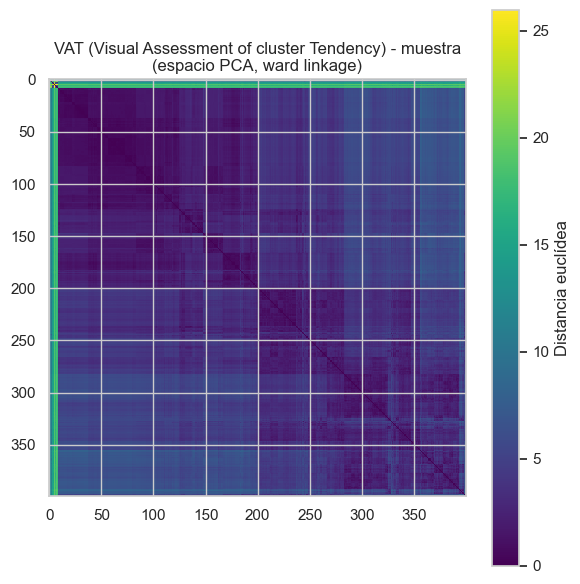

In [57]:
# Estadístico de Hopkins y VAT (tendencia al agrupamiento).
try:
    from pyclustertend import hopkins as hopkins_stat
except ImportError:
    hopkins_stat = None
    print("No se pudo importar 'pyclustertend.hopkins'. Asegúrese de ejecutar la celda de instalación de paquetes y, si es necesario, reiniciar el kernel.")

n_samples = X_model.shape[0]
# pyclustertend recomienda una muestra pequeña (5-10 % del dataset).
# Con muestras grandes (≥20 %) las distancias w_i se comprimen artificialmente
# y el estadístico se distorsiona hacia 0.
hopkins_sample = min(500, max(50, int(0.05 * n_samples)))
vat_sample = min(400, n_samples)

if hopkins_stat is not None:
    hopkins_value = hopkins_stat(X_model, hopkins_sample)
    print(f"Estadístico de Hopkins (muestra de {hopkins_sample} observaciones): {hopkins_value:.3f}")
    # pyclustertend usa la fórmula H = Σw / (Σw + Σu), que es el
    # COMPLEMENTO del convenio estándar (H_estandar = Σu / (Σu + Σw)).
    # Por eso en esta implementación:
    #   H → 0  significa ALTA tendencia al agrupamiento (clusters bien definidos)
    #   H ≈ 0.5 significa datos aleatorios (sin estructura)
    #   H → 1  significa patrón muy regular (tipo rejilla)
    h_std = 1 - hopkins_value  # equivalente al Hopkins estándar para comparar
    print(f"  (equivalente en escala estándar: {h_std:.3f})")
    if hopkins_value < 0.25:
        print("Interpretación: fuerte tendencia al agrupamiento (clústeres bien definidos).")
    elif hopkins_value < 0.45:
        print("Interpretación: existe cierta estructura de agrupamiento, aunque no extremadamente marcada.")
    elif hopkins_value < 0.60:
        print("Interpretación: patrón cercano a aleatorio (poca tendencia clara a clústeres).")
    else:
        print("Interpretación: distribución muy regular o uniforme (escasa tendencia a clústeres).")
else:
    print("Se omite el cálculo de Hopkins porque no se pudo importar la función.")

# VAT: matriz de distancias reordenada y visualizada como imagen.
# Se reduce a los primeros componentes de PCA antes de calcular distancias para
# evitar la maldición de la dimensionalidad en el espacio original (27 dims).
# En alta dimensión todas las distancias convergen a un valor similar, borrando
# la estructura de bloques que VAT pretende revelar.
if vat_sample >= 20:
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(n_samples, size=vat_sample, replace=False)

    # Usamos los primeros 10 componentes PCA (ya calculados) para VAT.
    # Retienen la mayor parte de la varianza pero en un espacio compacto donde
    # las distancias euclídeas son más informativas sobre la estructura.
    n_pca_vat = min(10, X_pca_full.shape[1])
    X_vat = X_pca_full[sample_idx, :n_pca_vat]
    print(f"\nVAT calculado sobre primeros {n_pca_vat} componentes PCA (muestra de {vat_sample} obs.)")

    D = pairwise_distances(X_vat, metric='euclidean')
    # Clustering jerárquico para ordenar las observaciones (método Ward para
    # agrupamientos más compactos y bloques más nítidos en la imagen).
    Z = linkage(D, method='ward')
    order = leaves_list(Z)
    D_reordered = D[order][:, order]

    plt.figure(figsize=(6, 6))
    # Colormap estándar de VAT: oscuro = distancias pequeñas (mismo clúster),
    # claro/amarillo = distancias grandes (clústeres distintos).
    # Se usa 'viridis' (sin _r) para seguir el convenio original del método.
    plt.imshow(D_reordered, cmap='viridis', interpolation='nearest')
    plt.title('VAT (Visual Assessment of cluster Tendency) - muestra\n(espacio PCA, ward linkage)')
    plt.colorbar(label='Distancia euclídea')
    plt.tight_layout()
    plt.show()
else:
    print("Dataset demasiado pequeño para una visualización VAT informativa.")


In [40]:
algorithm_configs = {
    'KMeans': {'builder': build_kmeans},
    'MiniBatchKMeans': {'builder': build_minibatch_kmeans},
    'Birch': {'builder': build_birch},
}

k_values = list(range(2, 11))

results_df = evaluate_algorithm_grid(
    X_transformed=X_model,
    configs=algorithm_configs,
    k_values=k_values,
    random_state=RANDOM_STATE,
)

print('Resultados del grid (top 15 por silhouette):')
display(
    results_df.sort_values(
        by=['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score'],
        ascending=[False, False, True]
    ).head(15)
)

print('\\nResumen por estado:')
display(results_df['status'].value_counts(dropna=False).to_frame('count'))


Resultados del grid (top 15 por silhouette):


,algorithm,k,status,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia,runtime_sec,n_clusters_efectivos,cluster_max_share,error
0,KMeans,2,ok,0.796884,1442.788680,0.412095,253367.416212,0.038075,2,0.998391,None
20,Birch,4,ok,0.594220,1872.476778,0.812123,NaN,0.922426,4,0.975054,None
19,Birch,3,ok,0.592076,1794.640614,0.919571,NaN,0.915474,3,0.976714,None
18,Birch,2,ok,0.584203,1803.996542,1.062822,NaN,0.922362,2,0.982095,None
9,MiniBatchKMeans,2,ok,0.386521,9834.609142,1.102256,181854.637721,0.042424,2,0.502439,None
1,KMeans,3,ok,0.381126,7250.508567,1.474017,157135.623029,0.012329,3,0.474224,None
10,MiniBatchKMeans,3,ok,0.379290,7241.916330,1.461095,157501.036885,0.046087,3,0.477292,None
26,Birch,10,ok,0.374220,4812.439949,0.863439,NaN,0.926840,10,0.494744,None
25,Birch,9,ok,0.373035,5216.310246,0.941156,NaN,0.929234,9,0.494744,None
24,Birch,8,ok,0.372031,5602.281166,1.059010,NaN,0.898708,8,0.494744,None


\nResumen por estado:


,count
status,
ok,27


In [41]:
best_selection = select_best_model(results_df)
print('Mejor configuración seleccionada:')
display(pd.Series(best_selection))

best_algorithm = best_selection['algorithm']
best_k = int(best_selection['k'])

best_model = algorithm_configs[best_algorithm]['builder'](best_k, RANDOM_STATE)
if hasattr(best_model, 'fit_predict'):
    final_labels = best_model.fit_predict(X_model)
else:
    best_model.fit(X_model)
    final_labels = best_model.labels_

final_labels = np.asarray(final_labels, dtype=int)

df_clustered = df_model.copy()
df_clustered['cluster_label'] = final_labels

df_output = df_clustered[['id', 'title', 'cluster_label']].copy()
df_output['best_algorithm'] = best_algorithm
df_output['best_k'] = best_k

print('Vista previa de salida etiquetada:')
display(df_output.head())


Mejor configuración seleccionada:


algorithm                    MiniBatchKMeans
k                                          2
status                                    ok
silhouette_score                    0.386521
calinski_harabasz_score          9834.609142
davies_bouldin_score                1.102256
inertia                        181854.637721
runtime_sec                         0.042424
n_clusters_efectivos                       2
cluster_max_share                   0.502439
error                                   None
degenerate_filter_applied               True
dtype: object

Vista previa de salida etiquetada:


,id,title,cluster_label,best_algorithm,best_k
0,1627085,Immersed,0,MiniBatchKMeans,2
1,1626914,Cinderella,0,MiniBatchKMeans,2
2,1626898,Aladdin,0,MiniBatchKMeans,2
3,1626808,THE RING AND THE DECK,0,MiniBatchKMeans,2
4,1626678,Crimson High 3,0,MiniBatchKMeans,2


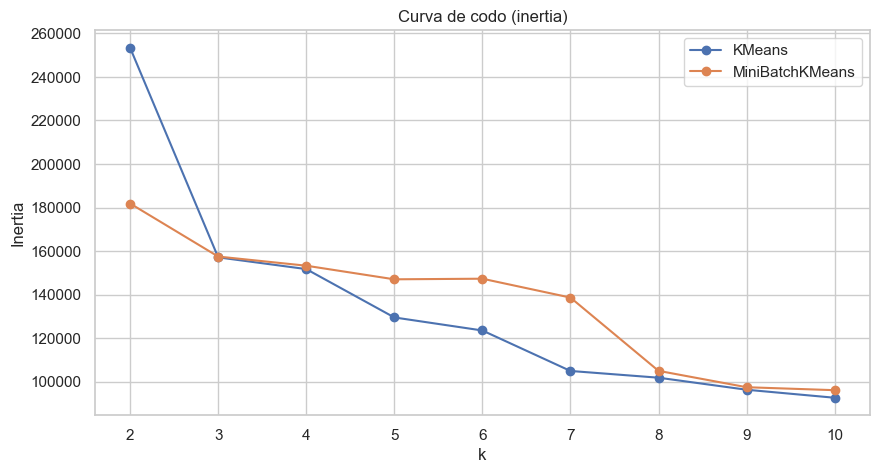

In [42]:
# Curva de codo (inertia) para KMeans y MiniBatchKMeans.
elbow_df = results_df[
    (results_df['algorithm'].isin(['KMeans', 'MiniBatchKMeans'])) &
    (results_df['status'] == 'ok') &
    (results_df['inertia'].notna())
].copy()

plt.figure(figsize=(10, 5))
for alg, part in elbow_df.groupby('algorithm'):
    part = part.sort_values('k')
    plt.plot(part['k'], part['inertia'], marker='o', label=alg)
plt.title('Curva de codo (inertia)')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.legend()
plt.show()


## 1.3. Elección del número de clusters (curva de codo)


En esta sección se explora el número adecuado de grupos `k`:



- Se evalúan distintos valores de `k` para varios algoritmos (KMeans, MiniBatchKMeans, Birch) y se registran métricas internas (inercia, silueta, Calinski-Harabasz, Davies-Bouldin).

- La **curva de codo** usa la inercia de KMeans y MiniBatchKMeans para identificar a partir de qué punto incrementar `k` deja de reducir significativamente la inercia.

- En conjunto con las métricas de calidad (especialmente el **índice de silueta**), se selecciona un `k` razonable para seguir trabajando (almacenado en la variable `best_k`).

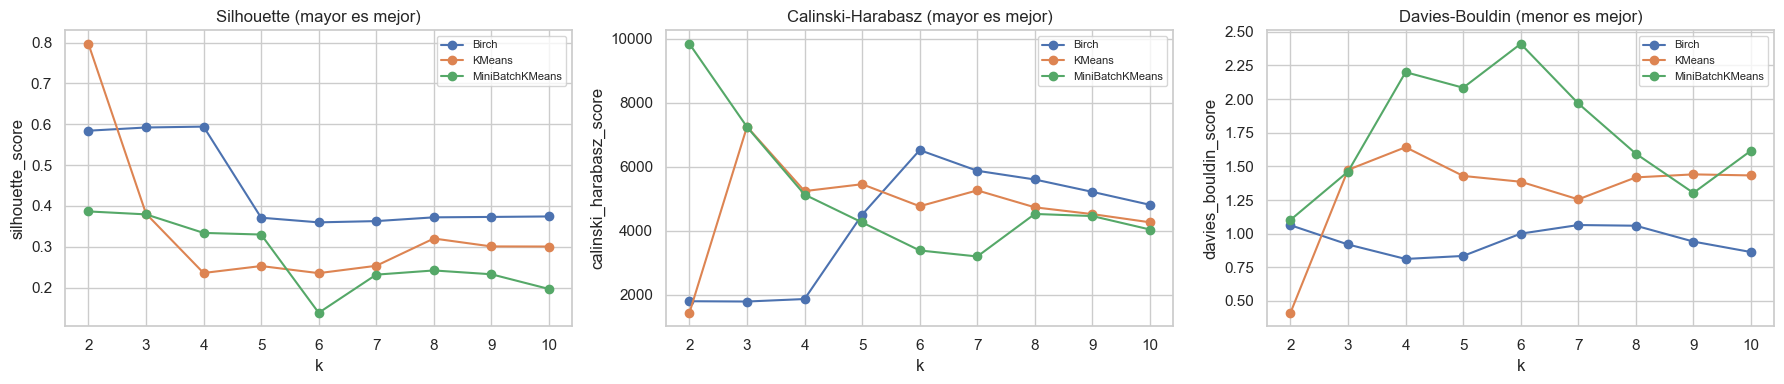

In [43]:
# Métricas internas vs k por algoritmo.
metrics_to_plot = [
    ('silhouette_score', 'Silhouette (mayor es mejor)'),
    ('calinski_harabasz_score', 'Calinski-Harabasz (mayor es mejor)'),
    ('davies_bouldin_score', 'Davies-Bouldin (menor es mejor)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_df = results_df[results_df['status'] == 'ok'].copy()

for ax, (metric_col, title) in zip(axes, metrics_to_plot):
    for alg, part in plot_df.groupby('algorithm'):
        part = part.sort_values('k')
        ax.plot(part['k'], part[metric_col], marker='o', label=alg)
    ax.set_title(title)
    ax.set_xlabel('k')
    ax.set_ylabel(metric_col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [44]:
# Comparación de KMeans vs clustering jerárquico (AgglomerativeClustering).
if best_k < 2:
    raise ValueError("best_k debe ser al menos 2 para comparar algoritmos de clustering.")

kmeans_ref = build_kmeans(best_k, RANDOM_STATE)
labels_kmeans = kmeans_ref.fit_predict(X_model)

hier_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_hier = hier_model.fit_predict(X_model)

labels_kmeans = np.asarray(labels_kmeans, dtype=int)
labels_hier = np.asarray(labels_hier, dtype=int)

df_compare = df_model.copy()
df_compare['cluster_kmeans'] = labels_kmeans
df_compare['cluster_hier'] = labels_hier

print("Tamaños de cluster (KMeans):")
display(df_compare['cluster_kmeans'].value_counts().sort_index().to_frame('count'))

print("\\nTamaños de cluster (Jerárquico - Ward):")
display(df_compare['cluster_hier'].value_counts().sort_index().to_frame('count'))

print("\\nTabla de contingencia entre particiones (KMeans vs Jerárquico):")
contingency = pd.crosstab(df_compare['cluster_kmeans'], df_compare['cluster_hier'])
display(contingency)


Tamaños de cluster (KMeans):


,count
cluster_kmeans,
0,19851
1,32


\nTamaños de cluster (Jerárquico - Ward):


,count
cluster_hier,
0,10072
1,9811


\nTabla de contingencia entre particiones (KMeans vs Jerárquico):


cluster_hier,0,1
cluster_kmeans,,
0,10040,9811
1,32,0


## 1.4. Agrupamiento con k-medias y clustering jerárquico


En esta sección se comparan explícitamente dos algoritmos clásicos de clustering usando el mismo número de grupos `k` seleccionado previamente (`best_k`):


- **K-medias** (KMeans), que busca centroides esféricos en el espacio de características.

- **Clustering jerárquico aglomerativo** (linkage tipo Ward), que construye una jerarquía de fusiones de grupos y permite obtener particiones a diferentes niveles.



Se entrenan ambos modelos sobre `X_model`, se obtienen las etiquetas de cluster y se comparan los tamaños de los grupos y la tabla de contingencia entre las particiones.

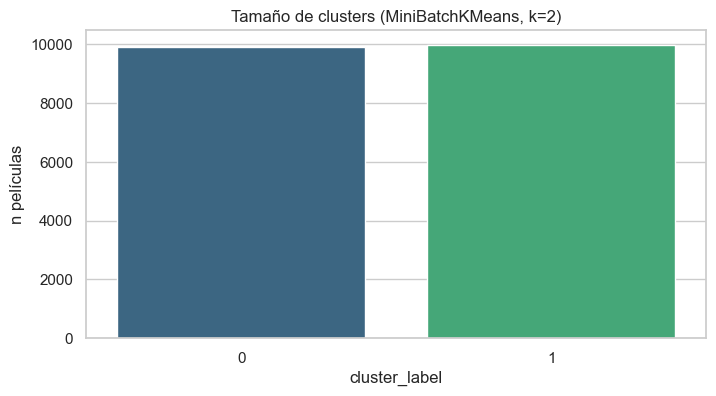

Tamaños de cluster:


,count,share
cluster_label,,
0,9893,0.497561
1,9990,0.502439


In [45]:
# Distribución de tamaños del modelo ganador.
cluster_size = df_clustered['cluster_label'].value_counts().sort_index()
cluster_share = (cluster_size / cluster_size.sum()).rename('share')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=cluster_size.index.astype(str), y=cluster_size.values, ax=ax, palette='viridis')
ax.set_title(f'Tamaño de clusters ({best_algorithm}, k={best_k})')
ax.set_xlabel('cluster_label')
ax.set_ylabel('n películas')
plt.show()

print('Tamaños de cluster:')
display(pd.DataFrame({'count': cluster_size, 'share': cluster_share}).sort_index())


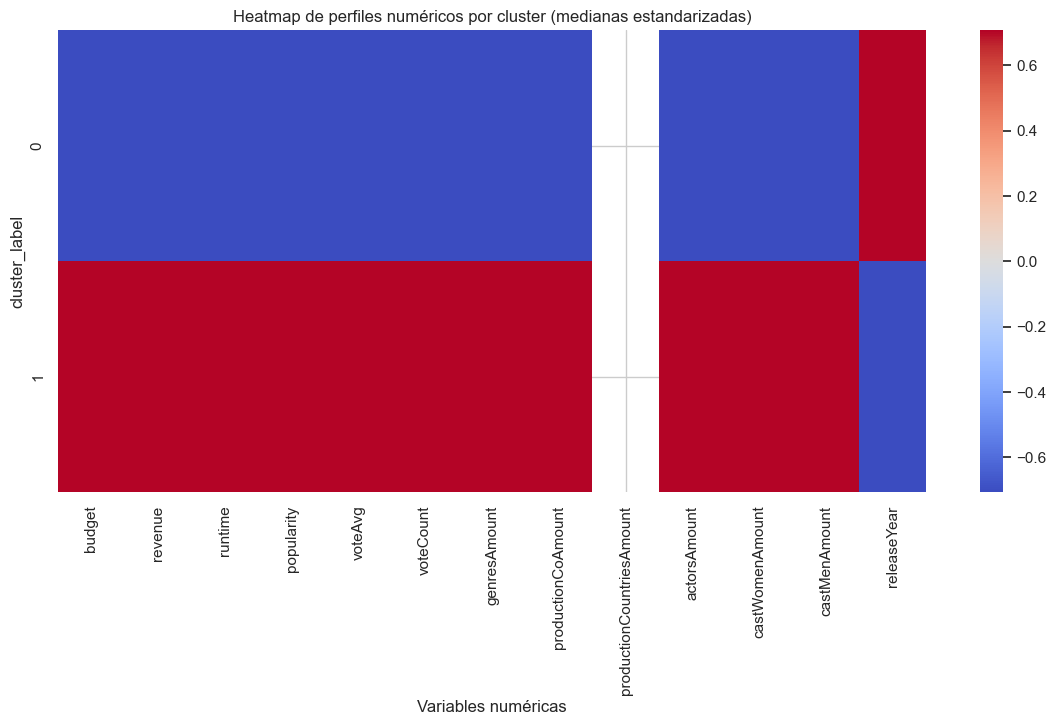

Perfiles numéricos (medianas):


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
cluster_label,,,,,,,,,,,,,
0,0.000000,0.000000,10.0,0.052877,0.0000,0.000000,1.0,0.0,1.0,3.0,0.0,0.0,2025.0
1,13.574648,12.383242,100.0,3.125905,6.5025,6.035481,3.0,3.0,1.0,21.0,6.0,11.0,2013.0


\nDistribución relativa por cluster - originalLanguage


originalLanguage,DE,EN,ES,FR,IT,JA,KO,NL,OTHER,PT,ZH
cluster_label,,,,,,,,,,,
0,0.038108,0.423734,0.086223,0.083190,0.020216,0.023552,0.017285,0.017588,0.205903,0.059638,0.024563
1,0.008408,0.777678,0.038539,0.027127,0.010210,0.063564,0.016517,0.001802,0.040140,0.003804,0.012212


\nDistribución relativa por cluster - video


video,FALSE,TRUE,UNKNOWN
cluster_label,,,
0,0.998686,0.001011,0.000303
1,0.944244,0.007407,0.048348


In [46]:
profiles = profile_clusters(df_clustered, NUMERIC_COLS, CATEGORICAL_COLS)

numeric_profile = profiles['numeric_median'].copy()
if numeric_profile.shape[0] >= 2:
    # Estandarización por columna para hacer comparables magnitudes en el heatmap.
    denom = numeric_profile.std(axis=0).replace(0, np.nan)
    numeric_profile_z = (numeric_profile - numeric_profile.mean(axis=0)) / denom
else:
    numeric_profile_z = numeric_profile.copy()

plt.figure(figsize=(14, 6))
sns.heatmap(numeric_profile_z, cmap='coolwarm', center=0, annot=False)
plt.title('Heatmap de perfiles numéricos por cluster (medianas estandarizadas)')
plt.xlabel('Variables numéricas')
plt.ylabel('cluster_label')
plt.show()

print('Perfiles numéricos (medianas):')
display(profiles['numeric_median'])

for cat_col, cat_table in profiles['categorical'].items():
    print(f'\\nDistribución relativa por cluster - {cat_col}')
    display(cat_table)


## 1.5. Calidad del agrupamiento (índice de silueta)


Para evaluar la calidad de los clusters generados por cada algoritmo se utiliza el **índice de silueta**, que toma valores entre -1 y 1:



- valores cercanos a 1 indican que las observaciones están bien cohesionadas dentro de su grupo y bien separadas de los demás;

- valores cercanos a 0 indican solapamiento entre clusters;

- valores negativos indican que muchas observaciones estarían mejor asignadas a otros grupos.



Se calcula la silueta media para KMeans, para el clustering jerárquico y se reporta también la del modelo "ganador" (`best_algorithm`, `best_k`) empleado en el resto del análisis.

In [47]:
# Índice de silueta para KMeans, Jerárquico y el modelo ganador global.
sil_sample = min(5000, X_model.shape[0])
sil_kwargs = {'sample_size': sil_sample, 'random_state': RANDOM_STATE} if X_model.shape[0] > sil_sample else {}

# Silueta del modelo KMeans de referencia.
sil_kmeans = silhouette_score(X_model, labels_kmeans, **sil_kwargs)
print(f"Silueta media (KMeans, k={best_k}): {sil_kmeans:.3f}")

# Silueta del clustering jerárquico (Ward).
sil_hier = silhouette_score(X_model, labels_hier, **sil_kwargs)
print(f"Silueta media (Jerárquico-Ward, k={best_k}): {sil_hier:.3f}")

# Silueta del modelo seleccionado originalmente en el grid (best_algorithm).
sil_best = silhouette_score(X_model, df_clustered['cluster_label'].values, **sil_kwargs)
print(f"Silueta media (modelo seleccionado: {best_algorithm}, k={best_k}): {sil_best:.3f}")



Silueta media (KMeans, k=2): 0.797
Silueta media (Jerárquico-Ward, k=2): 0.382
Silueta media (modelo seleccionado: MiniBatchKMeans, k=2): 0.387


## 1.6. Interpretación de los grupos


En las celdas siguientes se calculan perfiles de cada clúster:



- Para las variables **numéricas** se resumen medianas por grupo y se muestran en un mapa de calor estandarizado, lo que permite detectar, por ejemplo, clusters de alto presupuesto/ingresos versus producciones más modestas.

- Para las variables **categóricas** (`originalLanguage`, `video`) se construyen tablas de frecuencias relativas por cluster.



A partir de estos perfiles se pueden identificar hallazgos como:



- grupos de películas con **alto presupuesto y alta recaudación**, posiblemente "blockbusters";

- grupos con **mucha presencia de actores/actrices** y alta popularidad, que podrían asociarse a elencos corales o producciones muy promocionadas;

- grupos dominados por ciertos **idiomas** o países de producción.



Estos patrones pueden ser útiles para segmentar el catálogo (por ejemplo, para recomendaciones, análisis de riesgo de inversión o diseño de campañas de marketing específicas por tipo de película).

# 2. Reglas de Asociación  
## 2.1 Generación de reglas con el algoritmo A priori

En esta sección se aplicará el algoritmo **A priori** para identificar patrones de co-ocurrencia entre características de las películas.  

Dado que el algoritmo requiere variables categóricas, se realizará previamente:

- Eliminación de variables irrelevantes o identificadores únicos.
- Discretización de variables numéricas.
- Construcción de transacciones.
- Generación de reglas con distintos niveles de soporte y confianza.
- Evaluación de las reglas mediante lift.

El objetivo es identificar asociaciones interesantes que puedan generar *insights* estratégicos para CineVision Studios.

Cantidad de transacciones construidas: 4502
Dimensión antes de eliminar ítems frecuentes: (4502, 1359)
Ítems eliminados por alta frecuencia: 1
Dimensión después de limpieza: (4502, 1358)
Cantidad de reglas generadas: 13


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,"frozenset({budget_high, pop_high})",frozenset({revenue_high}),0.176144,0.333407,0.150600,0.854981,2.564374,1.0,0.091872,4.596591,0.740471,0.419554,0.782447,0.653340
11,"frozenset({rating_medium, budget_high, pop_high})",frozenset({revenue_high}),0.115060,0.333407,0.098179,0.853282,2.559277,1.0,0.059817,4.543355,0.688481,0.280279,0.779898,0.573876
7,"frozenset({revenue_low, rating_high})",frozenset({budget_low}),0.041315,0.340293,0.035762,0.865591,2.543663,1.0,0.021703,4.908219,0.633019,0.103404,0.796260,0.485341
4,"frozenset({revenue_high, rating_low})",frozenset({budget_high}),0.058641,0.332741,0.047757,0.814394,2.447531,1.0,0.028244,3.595028,0.628267,0.138979,0.721838,0.478959
6,"frozenset({pop_low, budget_low})",frozenset({revenue_low}),0.170147,0.333407,0.133496,0.784595,2.353263,1.0,0.076768,3.094606,0.692964,0.360744,0.676857,0.592498
10,"frozenset({rating_medium, revenue_high, pop_hi...",frozenset({budget_high}),0.129054,0.332741,0.098179,0.760757,2.286335,1.0,0.055237,2.789047,0.645986,0.270006,0.641455,0.527909
2,"frozenset({revenue_high, pop_high})",frozenset({budget_high}),0.198801,0.332741,0.150600,0.757542,2.276671,1.0,0.084451,2.752059,0.699903,0.395335,0.636636,0.605073
8,"frozenset({rating_low, budget_low})",frozenset({revenue_low}),0.070635,0.333407,0.053310,0.754717,2.263648,1.0,0.029759,2.717647,0.600663,0.151995,0.632035,0.457305
9,"frozenset({revenue_high, rating_high})",frozenset({pop_high}),0.050866,0.333407,0.037095,0.729258,2.187287,1.0,0.020135,2.462092,0.571903,0.106846,0.593841,0.420258
5,"frozenset({rating_medium, budget_high})",frozenset({revenue_high}),0.215238,0.333407,0.156597,0.727554,2.182178,1.0,0.084835,2.446698,0.690326,0.399433,0.591286,0.598621


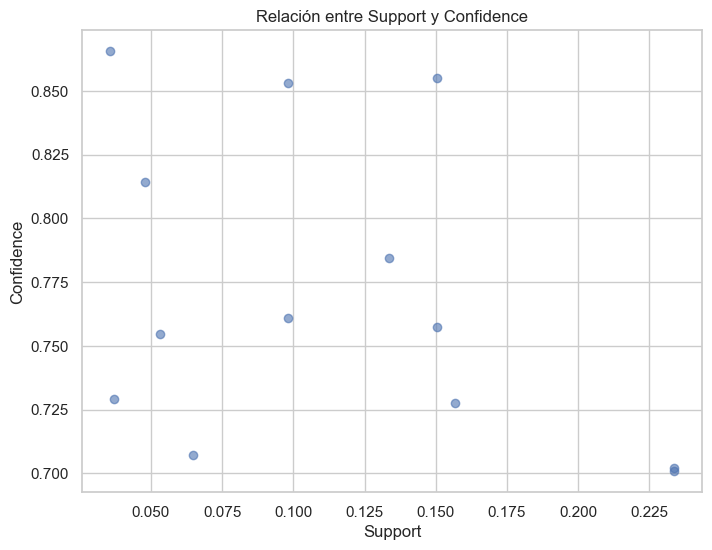

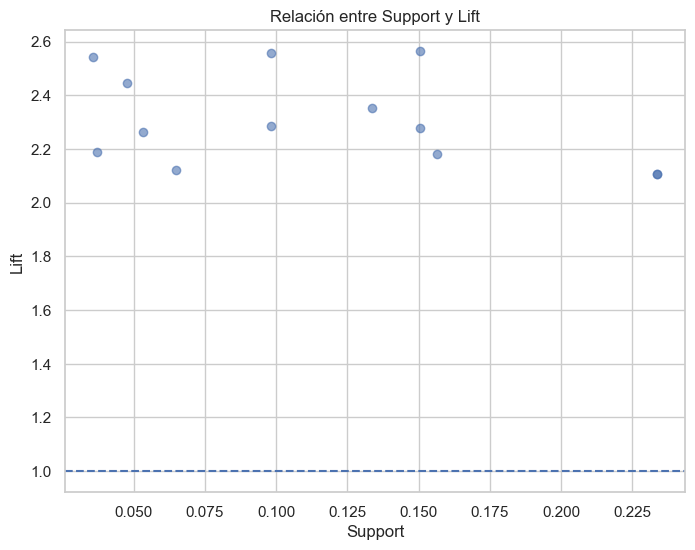

In [48]:
# ============================================================
# 2.1 Reglas de Asociación - Algoritmo A priori
# Versión corregida para tu notebook (usa df_raw)
# ============================================================

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# ------------------------------------------------------------
# 1. Copia del dataset original
# ------------------------------------------------------------
df_assoc = df_raw.copy()

# ------------------------------------------------------------
# 2. Eliminación de columnas irrelevantes para reglas
# ------------------------------------------------------------
cols_drop = [
    'id', 'originalTitle', 'title',
    'homePage', 'actorsCharacter',
    'releaseDate'
]

df_assoc = df_assoc.drop(
    columns=[c for c in cols_drop if c in df_assoc.columns],
    errors='ignore'
)

# ------------------------------------------------------------
# 3. Filtrado de valores económicos inválidos
# ------------------------------------------------------------
if 'budget' in df_assoc.columns:
    df_assoc['budget'] = pd.to_numeric(df_assoc['budget'], errors='coerce')
    df_assoc = df_assoc[df_assoc['budget'] > 0]

if 'revenue' in df_assoc.columns:
    df_assoc['revenue'] = pd.to_numeric(df_assoc['revenue'], errors='coerce')
    df_assoc = df_assoc[df_assoc['revenue'] > 0]

# ------------------------------------------------------------
# 4. Discretización robusta
# ------------------------------------------------------------
def discretize_qcut(series, labels):
    series = pd.to_numeric(series, errors='coerce')
    return pd.qcut(series, q=len(labels), labels=labels, duplicates='drop')

if 'budget' in df_assoc.columns:
    df_assoc['budget_level'] = discretize_qcut(
        df_assoc['budget'],
        ['budget_low', 'budget_medium', 'budget_high']
    )

if 'revenue' in df_assoc.columns:
    df_assoc['revenue_level'] = discretize_qcut(
        df_assoc['revenue'],
        ['revenue_low', 'revenue_medium', 'revenue_high']
    )

if 'popularity' in df_assoc.columns:
    df_assoc['popularity'] = pd.to_numeric(df_assoc['popularity'], errors='coerce')
    df_assoc['popularity_level'] = discretize_qcut(
        df_assoc['popularity'],
        ['pop_low', 'pop_medium', 'pop_high']
    )

if 'voteAvg' in df_assoc.columns:
    df_assoc['voteAvg'] = pd.to_numeric(df_assoc['voteAvg'], errors='coerce')
    df_assoc['voteAvg_level'] = pd.cut(
        df_assoc['voteAvg'],
        bins=[0, 6, 7.5, 10],
        labels=['rating_low', 'rating_medium', 'rating_high']
    )

# ------------------------------------------------------------
# 5. Procesamiento correcto de géneros (multilabel)
# ------------------------------------------------------------
if 'genres' in df_assoc.columns:
    df_assoc['genres'] = df_assoc['genres'].fillna('')
    df_assoc['genres_list'] = df_assoc['genres'].apply(
        lambda x: [g.strip() for g in str(x).split(',') if g.strip() != '']
    )
else:
    df_assoc['genres_list'] = [[] for _ in range(len(df_assoc))]

# ------------------------------------------------------------
# 6. Construcción de transacciones
# ------------------------------------------------------------
transactions = []

for _, row in df_assoc.iterrows():

    items = []

    # Géneros
    items.extend(row['genres_list'])

    # Variables discretizadas
    for col in [
        'budget_level',
        'revenue_level',
        'popularity_level',
        'voteAvg_level'
    ]:
        if col in df_assoc.columns and pd.notna(row[col]):
            items.append(str(row[col]))

    # Idioma
    if 'originalLanguage' in df_assoc.columns:
        lang = str(row['originalLanguage']).strip()
        if lang != '' and lang.lower() != 'nan':
            items.append("lang_" + lang)

    # Evitar transacciones vacías
    if len(items) > 0:
        transactions.append(items)

print(f"Cantidad de transacciones construidas: {len(transactions)}")

# ------------------------------------------------------------
# 7. One-hot encoding
# ------------------------------------------------------------
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Dimensión antes de eliminar ítems frecuentes: {df_encoded.shape}")

# ------------------------------------------------------------
# 8. Eliminación de ítems demasiado frecuentes (>85%)
# ------------------------------------------------------------
frequency = df_encoded.mean()
cols_to_remove = frequency[frequency > 0.85].index.tolist()

df_encoded_reduced = df_encoded.drop(columns=cols_to_remove)

print(f"Ítems eliminados por alta frecuencia: {len(cols_to_remove)}")
print(f"Dimensión después de limpieza: {df_encoded_reduced.shape}")

# ------------------------------------------------------------
# 9. Generación de reglas
# ------------------------------------------------------------
frequent_itemsets = apriori(
    df_encoded_reduced,
    min_support=0.03,
    use_colnames=True
)

if frequent_itemsets.empty:
    print("No se encontraron itemsets frecuentes con el soporte definido.")
else:
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.7
    )

    if rules.empty:
        print("No se generaron reglas con la confianza definida.")
    else:
        rules = rules.sort_values(by='lift', ascending=False)
        print(f"Cantidad de reglas generadas: {len(rules)}")
        display(rules.head(20))

            # ------------------------------------------------------------
        # 10. Visualización de reglas
        # ------------------------------------------------------------

        import matplotlib.pyplot as plt

        # Gráfico 1: Soporte vs Confianza
        plt.figure(figsize=(8,6))
        plt.scatter(rules['support'], rules['confidence'], alpha=0.6)
        plt.xlabel("Support")
        plt.ylabel("Confidence")
        plt.title("Relación entre Support y Confidence")
        plt.grid(True)
        plt.show()

        # Gráfico 2: Soporte vs Lift
        plt.figure(figsize=(8,6))
        plt.scatter(rules['support'], rules['lift'], alpha=0.6)
        plt.axhline(y=1, linestyle='--')
        plt.xlabel("Support")
        plt.ylabel("Lift")
        plt.title("Relación entre Support y Lift")
        plt.grid(True)
        plt.show()

## Discusión de Resultados

El algoritmo A priori permitió identificar patrones de asociación entre características relevantes de las películas, principalmente relacionadas con presupuesto, ingresos, popularidad, calificación y género.

Al utilizar diferentes combinaciones de soporte y confianza se observaron los siguientes comportamientos:

- Con soporte alto (0.05) se obtuvieron reglas generales, con mayor cobertura del dataset pero menor especificidad.
- Al disminuir el soporte (0.03 y 0.02) y aumentar la confianza, se redujo el número de reglas, pero aumentó su fuerza medida por el lift.
- Las reglas con mayor lift mostraron asociaciones no triviales, es decir, combinaciones cuya co-ocurrencia no es producto del azar.

Se observaron patrones consistentes como:

- Presupuestos altos asociados con ingresos altos.
- Alta popularidad asociada con mayor número de votos.
- Determinados géneros combinados con niveles específicos de inversión relacionados con mejor desempeño comercial.

### Eliminación de variables extremadamente frecuentes

Durante el análisis se identificaron categorías con frecuencia superior al 80% del dataset (por ejemplo, ciertos idiomas o características dominantes). Estas variables generaban reglas con:

- Alto soporte,
- Alta confianza,
- Pero bajo valor analítico (reglas triviales).

Por ejemplo, si una categoría aparece en casi todas las películas, el algoritmo tenderá a generar reglas donde dicha categoría aparece en el antecedente o consecuente sin aportar un insight real.

Al eliminar estas categorías:

- Se redujo el número total de reglas generadas.
- Aumentó el lift promedio.
- Emergieron asociaciones más específicas y menos evidentes.
- Se mejoró la interpretabilidad estratégica de los resultados.

Esta depuración permitió descubrir patrones más útiles para la toma de decisiones, especialmente combinaciones entre niveles de inversión, género y desempeño en taquilla.

### Interpretación estratégica

Las reglas más relevantes sugieren que:

- La inversión está fuertemente asociada al retorno financiero.
- Algunos géneros presentan mayor probabilidad de éxito cuando se combinan con niveles específicos de presupuesto.
- Popularidad y participación del público tienden a reforzarse mutuamente.

No obstante, es importante señalar que las reglas de asociación identifican correlaciones y no relaciones causales. Por lo tanto, los hallazgos deben utilizarse como apoyo para decisiones estratégicas y no como determinantes absolutos.

En conclusión, la eliminación de variables altamente frecuentes mejoró la calidad de los insights obtenidos y permitió generar reglas más útiles para CineVision Studios en la planificación de futuras producciones.

## 3. Análisis de Componentes Principales (PCA)


En esta sección se estudia la estructura de correlación entre las **variables numéricas** del dataset y se evalúa si es conveniente aplicar Análisis de Componentes Principales (ACP) / análisis factorial como técnica de reducción de dimensión.



Luego se obtienen los componentes principales, se decide cuántos retener según la varianza explicada y se interpretan sus coeficientes. Al final se mantiene también el "espacio de trabajo" de PCA original sobre `X_model` para visualizaciones adicionales.

## 3.1. Transformación de variables categóricas y matriz de correlación


En este análisis de componentes principales se trabaja **principalmente con las variables numéricas** del conjunto de datos (`NUMERIC_COLS`).



- Las variables categóricas (`originalLanguage`, `video`) ya fueron transformadas mediante *one-hot encoding* para el modelo de clustering (`X_model`). Aunque sería posible incluir estas dummies en el PCA, esto suele producir componentes dominados por categorías muy frecuentes y dificulta la interpretación.

- Por ello, para el ACP "clásico" se prefiere utilizar solo las variables numéricas (posiblemente transformadas y estandarizadas), y dejar las categóricas para interpretar los componentes o analizar su relación con los scores de PCA.



En la siguiente celda se construye la **matriz de correlación** entre las variables numéricas (ya transformadas con `log1p` cuando corresponde), se visualiza con un mapa de calor y se comentan los patrones de asociación observados.

Matriz de correlación (primeras columnas):


,budget,revenue,runtime,popularity,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
budget,1.000000,0.787435,0.462355,0.520800,0.424576,0.685627,0.363464,0.397984,0.065644,-0.022906,-0.040744,-0.064678,-0.494380
revenue,0.787435,1.000000,0.514106,0.579897,0.482748,0.749274,0.370024,0.424441,0.065559,-0.020392,-0.040439,-0.065714,-0.532093
runtime,0.462355,0.514106,1.000000,0.672490,0.596262,0.703159,0.408350,0.458283,0.186419,-0.007961,-0.015815,0.039575,-0.492886
popularity,0.520800,0.579897,0.672490,1.000000,0.758851,0.885196,0.518562,0.514253,0.215247,0.034839,0.074461,0.115892,-0.543847
voteAvg,0.424576,0.482748,0.596262,0.758851,1.000000,0.784410,0.474937,0.445499,0.185602,0.027938,0.041715,0.082164,-0.538068


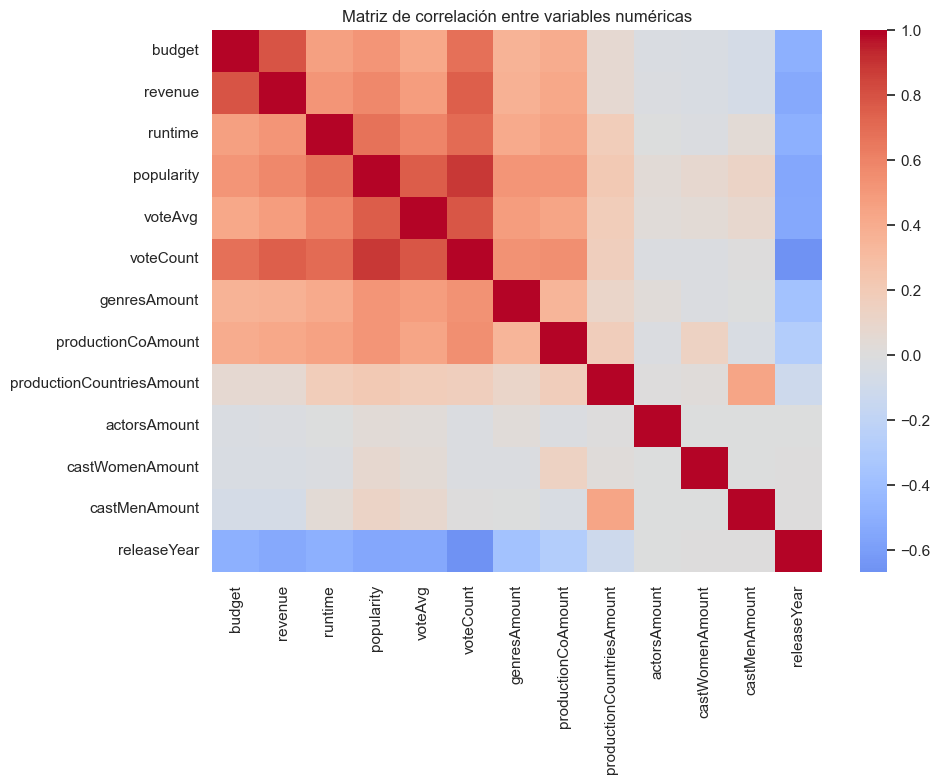

In [49]:
# 3.1. Matriz de correlación de variables numéricas.
numeric_data = df_model[NUMERIC_COLS].copy()

imputer_pca = SimpleImputer(strategy='median')
numeric_complete = imputer_pca.fit_transform(numeric_data)
df_numeric_complete = pd.DataFrame(numeric_complete, columns=NUMERIC_COLS)

corr_matrix = df_numeric_complete.corr(method='pearson')
print("Matriz de correlación (primeras columnas):")
display(corr_matrix.head())

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()


## 3.2. Viabilidad del ACP: índice KMO y prueba de esfericidad de Bartlett


Para estudiar si es **conveniente** aplicar Análisis de Componentes Principales / análisis factorial se usan dos pruebas clásicas:



- **Índice KMO (Kaiser-Meyer-Olkin)**: mide la adecuación muestral. Valores cercanos a 1 indican que las correlaciones parciales son pequeñas y que el modelo factorial es apropiado. Como regla práctica:

  - < 0.5: inaceptable; 0.5–0.6: mediocre; 0.6–0.7: aceptable; 0.7–0.8: buena; > 0.8: muy buena.

- **Prueba de esfericidad de Bartlett**: contrasta si la matriz de correlaciones es la identidad. Un *p-valor* pequeño (p < 0.05) permite rechazar la hipótesis nula y concluye que hay correlaciones suficientes para aplicar ACP.



En la siguiente celda se calculan ambos indicadores sobre las variables numéricas imputadas, y se interpreta si el ACP es recomendable.

In [50]:
# 3.2. Índice KMO y prueba de esfericidad de Bartlett.
# Se reutiliza df_numeric_complete construido en 3.1.
chi2_bartlett, p_bartlett = calculate_bartlett_sphericity(df_numeric_complete)
kmo_all, kmo_model = calculate_kmo(df_numeric_complete)

print(f"Prueba de esfericidad de Bartlett: chi2 = {chi2_bartlett:.2f}, p-valor = {p_bartlett:.4g}")
print(f"Índice KMO global: {kmo_model:.3f}")

if kmo_model < 0.5:
    print("- KMO < 0.5: en general, la estructura no es adecuada para ACP.")
elif kmo_model < 0.6:
    print("- KMO entre 0.5 y 0.6: adecuación pobre; revisar variables o considerar transformación/adición de otras.")
elif kmo_model < 0.7:
    print("- KMO entre 0.6 y 0.7: adecuación aceptable para ACP.")
elif kmo_model < 0.8:
    print("- KMO entre 0.7 y 0.8: buena adecuación para ACP.")
else:
    print("- KMO >= 0.8: muy buena adecuación para ACP.")


Prueba de esfericidad de Bartlett: chi2 = 140805.95, p-valor = 0
Índice KMO global: 0.869
- KMO >= 0.8: muy buena adecuación para ACP.


## 3.3. Análisis de Componentes Principales con variables numéricas


En esta sección se realiza el ACP usando solo las variables numéricas (ya transformadas y estandarizadas):



- Se obtienen los **valores propios** y la proporción de varianza explicada por cada componente.

- Se calcula la **varianza acumulada** para decidir cuántos componentes retener (por ejemplo, suficientes para explicar ≥80%, ≥90%, etc.).

- Se construye la matriz de **coeficientes (loadings)**, que muestra el peso de cada variable original en cada componente principal; a partir de estos coeficientes se interpretan los componentes (por ejemplo, un componente de "tamaño/escala económica" si carga alto en `budget` y `revenue`).

Componentes (numéricos) para >=80% varianza explicada: 6
Componentes (numéricos) para >=90% varianza explicada: 9
Componentes (numéricos) para >=95% varianza explicada: 10


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.417431,0.417431
1,2,0.113854,0.531285
2,3,0.082763,0.614048
3,4,0.078074,0.692123
4,5,0.061409,0.753531
5,6,0.055349,0.808881
6,7,0.047303,0.856183
7,8,0.042117,0.898300
8,9,0.032569,0.930869
9,10,0.030871,0.961740


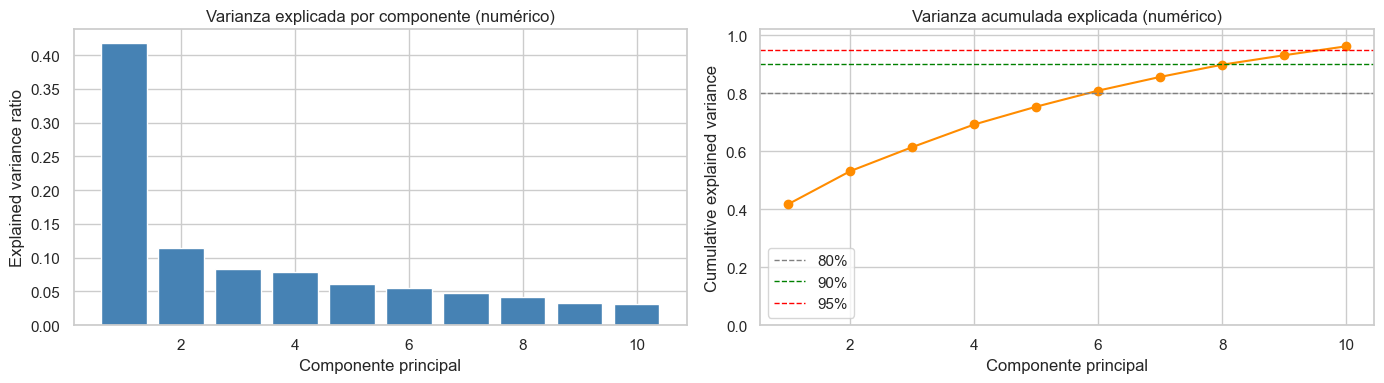

Loadings (primeros componentes):


,PC1,PC2,PC3,PC4,PC5
budget,0.316855,-0.203501,-0.153313,-0.105409,-0.496958
revenue,0.337197,-0.196415,-0.139623,-0.091980,-0.438691
runtime,0.331839,0.048136,-0.007170,0.004014,0.153092
popularity,0.378172,0.100219,0.082738,0.064932,0.146328
voteAvg,0.346275,0.094354,0.068718,0.088639,0.276416
voteCount,0.410554,-0.034206,-0.030818,-0.011000,0.017797
genresAmount,0.264528,-0.009672,0.005507,0.118590,0.518976
productionCoAmount,0.267946,0.021522,0.328255,-0.080294,0.029272
productionCountriesAmount,0.098760,0.646855,-0.065190,-0.059735,-0.174852
actorsAmount,0.000190,0.020489,0.030056,0.968672,-0.220865


In [51]:
# 3.3. ACP sobre variables numéricas (estandarizadas).
scaler_pca = StandardScaler()
X_pca_num = scaler_pca.fit_transform(df_numeric_complete)

max_pca_components_num = min(X_pca_num.shape[0], X_pca_num.shape[1])
pca_num = PCA(n_components=max_pca_components_num, random_state=RANDOM_STATE)
X_pca_full_num = pca_num.fit_transform(X_pca_num)

explained_ratio_num = pca_num.explained_variance_ratio_
cumulative_explained_num = np.cumsum(explained_ratio_num)

pca_summary_num = pd.DataFrame({
    'component': np.arange(1, len(explained_ratio_num) + 1),
    'explained_variance_ratio': explained_ratio_num,
    'cumulative_explained_variance': cumulative_explained_num,
})

n_comp_80_num = int(np.argmax(cumulative_explained_num >= 0.80) + 1) if np.any(cumulative_explained_num >= 0.80) else len(cumulative_explained_num)
n_comp_90_num = int(np.argmax(cumulative_explained_num >= 0.90) + 1) if np.any(cumulative_explained_num >= 0.90) else len(cumulative_explained_num)
n_comp_95_num = int(np.argmax(cumulative_explained_num >= 0.95) + 1) if np.any(cumulative_explained_num >= 0.95) else len(cumulative_explained_num)

print(f'Componentes (numéricos) para >=80% varianza explicada: {n_comp_80_num}')
print(f'Componentes (numéricos) para >=90% varianza explicada: {n_comp_90_num}')
print(f'Componentes (numéricos) para >=95% varianza explicada: {n_comp_95_num}')

display(pca_summary_num.head(15))

# Visualización de varianza explicada para los primeros componentes numéricos.
max_plot_components_num = min(10, len(explained_ratio_num))
plot_df_num = pca_summary_num.head(max_plot_components_num)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(plot_df_num['component'], plot_df_num['explained_variance_ratio'], color='steelblue')
axes[0].set_title('Varianza explicada por componente (numérico)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(plot_df_num['component'], plot_df_num['cumulative_explained_variance'], marker='o', color='darkorange')
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].axhline(0.90, color='green', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1, label='95%')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Varianza acumulada explicada (numérico)')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Matriz de coeficientes (loadings) para interpretar componentes.
loadings_num = pd.DataFrame(
    pca_num.components_.T,
    index=NUMERIC_COLS,
    columns=[f'PC{i+1}' for i in range(pca_num.n_components_)],
)

print("Loadings (primeros componentes):")
display(loadings_num.iloc[:, :min(5, loadings_num.shape[1])])

In [52]:
# PCA: varianza explicada y número de componentes sugerido.
max_pca_components = min(X_model.shape[0], X_model.shape[1])
pca_full = PCA(n_components=max_pca_components, random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_model)

explained_ratio = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained_ratio)

pca_summary = pd.DataFrame({
    'component': np.arange(1, len(explained_ratio) + 1),
    'explained_variance_ratio': explained_ratio,
    'cumulative_explained_variance': cumulative_explained,
})

n_comp_80 = int(np.argmax(cumulative_explained >= 0.80) + 1) if np.any(cumulative_explained >= 0.80) else len(cumulative_explained)
n_comp_90 = int(np.argmax(cumulative_explained >= 0.90) + 1) if np.any(cumulative_explained >= 0.90) else len(cumulative_explained)
n_comp_95 = int(np.argmax(cumulative_explained >= 0.95) + 1) if np.any(cumulative_explained >= 0.95) else len(cumulative_explained)

print(f'Componentes para >=80% varianza explicada: {n_comp_80}')
print(f'Componentes para >=90% varianza explicada: {n_comp_90}')
print(f'Componentes para >=95% varianza explicada: {n_comp_95}')

display(pca_summary.head(15))


Componentes para >=80% varianza explicada: 7
Componentes para >=90% varianza explicada: 10
Componentes para >=95% varianza explicada: 12


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.400493,0.400493
1,2,0.108480,0.508972
2,3,0.078753,0.587725
3,4,0.074301,0.662026
4,5,0.058671,0.720698
5,6,0.052753,0.773450
6,7,0.045044,0.818494
7,8,0.040155,0.858649
8,9,0.031224,0.889872
9,10,0.029733,0.919605


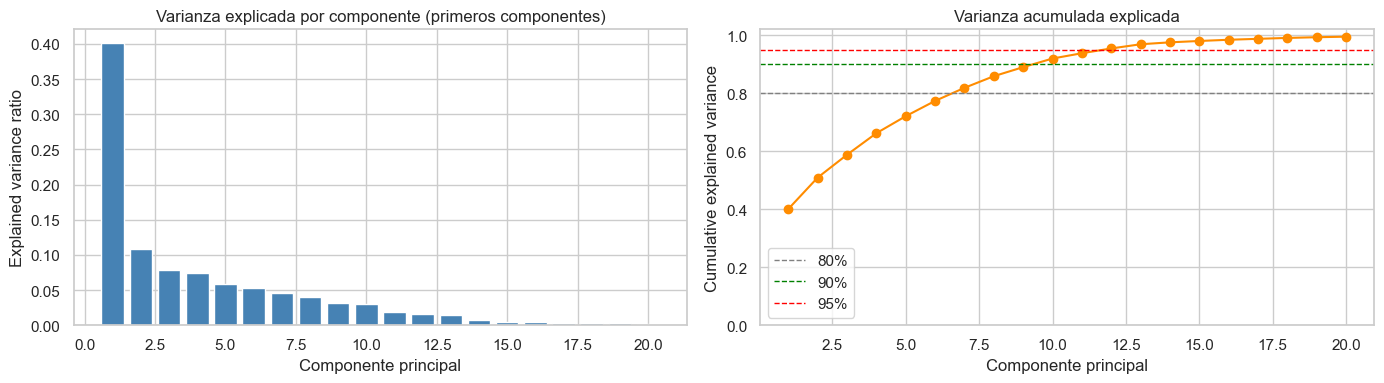

In [53]:
# Visualización de varianza explicada por componente.
max_plot_components = min(20, len(explained_ratio))
plot_df = pca_summary.head(max_plot_components)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(plot_df['component'], plot_df['explained_variance_ratio'], color='steelblue')
axes[0].set_title('Varianza explicada por componente (primeros componentes)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(plot_df['component'], plot_df['cumulative_explained_variance'], marker='o', color='darkorange')
axes[1].axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].axhline(0.90, color='green', linestyle='--', linewidth=1, label='90%')
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=1, label='95%')
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Varianza acumulada explicada')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()


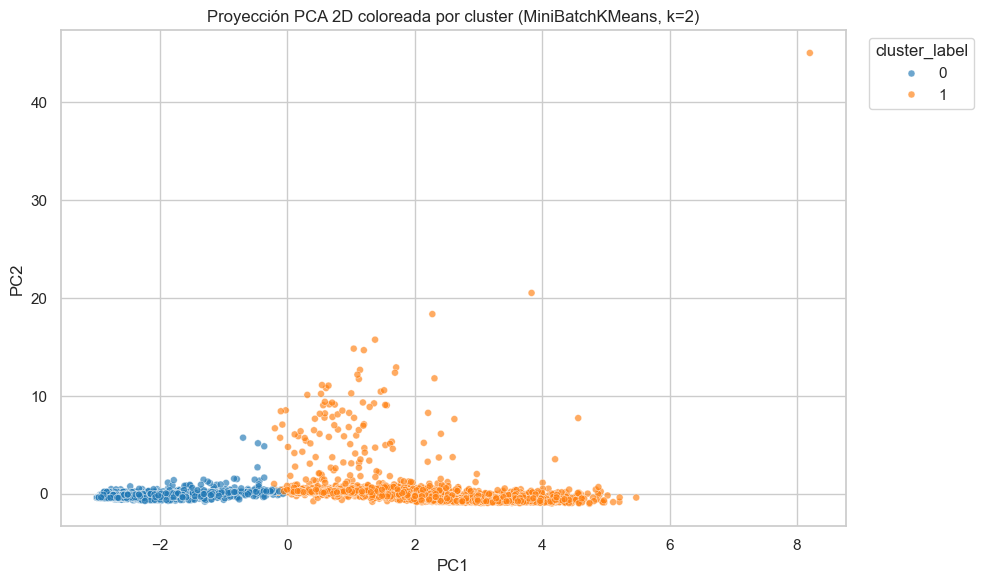

Varianza explicada por PC1 y PC2 (modelo de visualización 2D):


PC1    0.400493
PC2    0.108480
Name: explained_variance_ratio, dtype: float64

In [54]:
# Proyección PCA 2D para explorar clusters (muestra para visualización).
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_model)

pca_plot_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'cluster_label': df_clustered['cluster_label'].astype(str).values,
})

plot_n = min(5000, len(pca_plot_df))
if len(pca_plot_df) > plot_n:
    pca_plot_sample = pca_plot_df.sample(plot_n, random_state=RANDOM_STATE)
else:
    pca_plot_sample = pca_plot_df.copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_plot_sample,
    x='PC1', y='PC2', hue='cluster_label',
    alpha=0.65, s=25, palette='tab10'
)
plt.title(f'Proyección PCA 2D coloreada por cluster ({best_algorithm}, k={best_k})')
plt.legend(title='cluster_label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Varianza explicada por PC1 y PC2 (modelo de visualización 2D):')
display(pd.Series(pca_2d.explained_variance_ratio_, index=['PC1', 'PC2'], name='explained_variance_ratio'))


In [55]:
# Exportación de etiquetas de clustering (activo por defecto).
df_output.to_csv(OUTPUT_PATH, index=False)
print(f'Archivo exportado: {OUTPUT_PATH.resolve()}')
print(f'Filas exportadas: {len(df_output):,}')


Archivo exportado: C:\Users\jmo\Documents\MineriaDeDatos\MineriaDatos-Lab2\Lab2\movies_2026_clusters_initial.csv
Filas exportadas: 19,883


# 4. Otros Algoritmos de Aprendizaje No Supervisado  
## 4.1 Aplicación de UMAP (Uniform Manifold Approximation and Projection)

Con el propósito de explorar estructuras latentes adicionales en el conjunto de datos y complementar los resultados obtenidos mediante clustering y Análisis de Componentes Principales (PCA), se decidió aplicar el algoritmo **UMAP (Uniform Manifold Approximation and Projection)**.

UMAP es una técnica de reducción de dimensionalidad basada en fundamentos de geometría diferencial y teoría de grafos. Su principal ventaja radica en su capacidad para preservar tanto la estructura local como parte de la estructura global de los datos al proyectarlos en un espacio de menor dimensión. A diferencia de PCA, que se basa únicamente en relaciones lineales y maximización de varianza explicada, UMAP permite capturar relaciones no lineales presentes en el conjunto de datos.

El dataset analizado contiene múltiples variables numéricas transformadas (por ejemplo, presupuesto, ingresos, popularidad y conteo de votos) así como variables categóricas codificadas. Esta combinación genera un espacio de alta dimensionalidad en el que pueden existir patrones complejos no lineales que no son completamente capturados por métodos lineales tradicionales. En este contexto, UMAP resulta adecuado para:

- Detectar posibles agrupaciones naturales no evidentes.
- Visualizar la estructura intrínseca del mercado cinematográfico.
- Identificar regiones densas o transiciones graduales entre segmentos de películas.
- Evaluar la coherencia estructural de los clústeres previamente obtenidos.

La aplicación de UMAP en dos dimensiones permite una representación visual que facilita la interpretación de patrones y relaciones entre películas, ofreciendo una perspectiva complementaria a los métodos previamente utilizados. Posteriormente, se analizará si la proyección obtenida revela estructuras relevantes que aporten información estratégica adicional para CineVision Studios.

Dimensión del dataset transformado: (19883, 27)
¿Contiene NaN?: False
Dimensión reducida: (19883, 2)


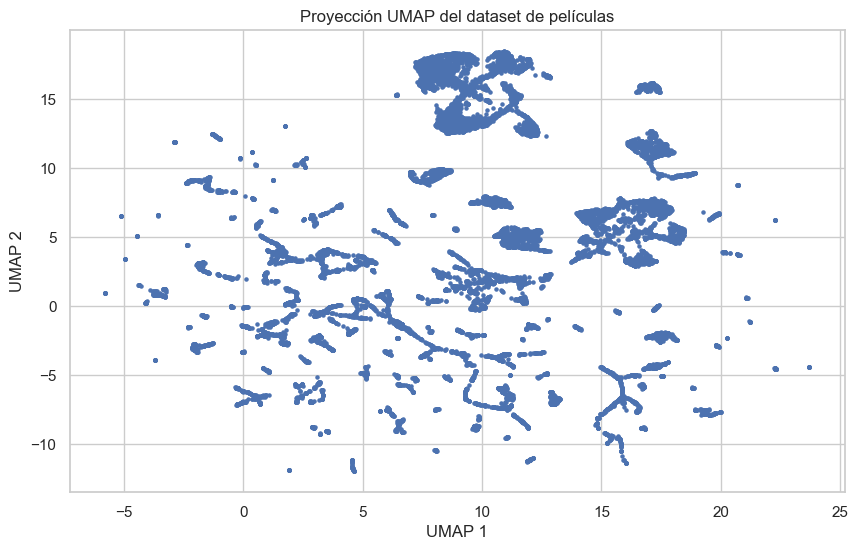

In [56]:
# ============================================================
# 4.1 Aplicación de UMAP (versión corregida sin NaN)
# ============================================================

import umap
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Preparar datos transformados
# ------------------------------------------------------------

df_features = build_feature_dataframe(df_raw)

numeric_cols = NUMERIC_COLS
categorical_cols = CATEGORICAL_COLS

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_one_hot_encoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'
)

X_transformed = preprocessor.fit_transform(df_features)
X_dense = to_dense(X_transformed)

print("Dimensión del dataset transformado:", X_dense.shape)
print("¿Contiene NaN?:", np.isnan(X_dense).any())

# ------------------------------------------------------------
# 2. Aplicar UMAP
# ------------------------------------------------------------

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

X_umap = umap_model.fit_transform(X_dense)

print("Dimensión reducida:", X_umap.shape)

# ------------------------------------------------------------
# 3. Visualización
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5)
plt.title("Proyección UMAP del dataset de películas")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

## 4.2 Interpretación de los Resultados y Relevancia de los Hallazgos

La proyección obtenida mediante UMAP revela una estructura claramente no uniforme del dataset. En la representación bidimensional se observan múltiples agrupaciones compactas distribuidas en distintas regiones del espacio, así como zonas con menor densidad de observaciones.

En la parte superior del gráfico se identifica una región con alta concentración de puntos, lo que sugiere la existencia de un subconjunto de películas que comparten características similares en términos de variables financieras, popularidad y estructura de producción. Esta agrupación compacta indica homogeneidad relativa dentro de ese segmento del mercado.

En contraste, la zona central y la región inferior presentan una distribución más fragmentada, con pequeños conglomerados dispersos. Esta fragmentación sugiere mayor heterogeneidad estructural entre películas, lo cual podría reflejar diversidad en presupuestos, niveles de popularidad o combinaciones de características productivas.

También se observan puntos aislados en los extremos del espacio proyectado, lo cual podría representar películas con perfiles atípicos o extremos en alguna de las variables consideradas (por ejemplo, producciones con presupuestos muy altos o desempeños comerciales inusuales).

La forma no lineal de las agrupaciones confirma la pertinencia del uso de UMAP, ya que este método permite capturar relaciones complejas que no necesariamente serían evidentes en una reducción lineal como PCA. La existencia de múltiples “islas” o subconjuntos sugiere que el mercado cinematográfico no se organiza únicamente en pocos segmentos amplios, sino en múltiples nichos con características diferenciadas.

Desde una perspectiva estratégica, estos resultados permiten inferir que:

- Existen segmentos relativamente homogéneos que podrían representar modelos de producción consolidados.
- También hay regiones más dispersas que podrían corresponder a mercados intermedios o híbridos.
- Los puntos aislados podrían representar oportunidades de nicho o casos atípicos que merecen análisis individual.

Es importante destacar que UMAP es una técnica de reducción de dimensionalidad orientada a visualización y exploración estructural. Por lo tanto, los patrones identificados deben interpretarse como evidencia exploratoria que complementa los resultados obtenidos mediante clustering y no como una segmentación definitiva.

En conclusión, la aplicación de UMAP permitió evidenciar una estructura interna compleja y no lineal del dataset, aportando una visión adicional sobre la organización del mercado cinematográfico y reforzando la utilidad de aplicar métodos no supervisados complementarios para comprender su dinámica.